# Single phase flow
This tutorial serves as an introduction for how to set up and run a simulation in PorePy. This will be demonstrated by solving a single phase flow problem, which is done by first covering incompressible flow. 
The mathematical formulation of the problem can be found in the article [Keilegavlen et al. 2020](https://link.springer.com/article/10.1007/s10596-020-10002-5).

This part includes modifying the domain, boundary conditions, source terms, fluid parameters and time steps. Towards the end, we will also give a brief demonstration of how to export the simulation data for visualization purposes.

## Models in PorePy
A model in porepy is defined by a combination of Python classes, where each class covers its own aspect of the model.
These aspects are:

* Geometry
* Equations
* Variables
* Constitutive laws
* Boundary conditions
* Solution strategy


and they are combined using multiple inheritance in Python.
Since the model classes are composed with relatively advanced use of Python inheritance and mixin, the reader is highly encouraged to familiarize themselves with those concepts.
We will not visit the technicalities about this, so we refer to [this blog post](https://www.thedigitalcatonline.com/blog/2020/03/27/mixin-classes-in-python/) for an introduction on the topic. It is recommended to read this blog post before proceeding with this tutorial.

In PorePy all classes related to models except solution strategies are treated as Mixins. 
The solution strategy also defines an implicit contract between the functions used to run a simulation (run_time_dependent_problem) and the rest of the model.

Porepy provides complete models for several problems, and they are fully capable for running a simulation as they are. 
The user might be interested in modifying the model, and this is what we will cover in this tutorial.
The usual way of doing this is by overriding the pre-defined, default methods.

## Incompressible flow
As there already exists a model for the single phase flow problem in PorePy, running a simulation is possible with only a few lines of code.
The model can be found in the fluid_mass_balance.py file under the name ``SinglePhaseFlow``.

We start off by importing the necessary packages, and make a shorthand for the single phase flow model class:

In [1]:
import porepy as pp
import numpy as np
from porepy.models.fluid_mass_balance import SinglePhaseFlow

### Geometry
The default geometry is a unitary domain without any fractures, and we will therefore look at how to modify it. 
Here we will demonstrate how this is done by overriding methods found within the ``set_geometry`` method found in ``pp.ModelGeometry``. 
This is where the geometry related methods and information are located.

More specifically, we will override the following methods:

* ``set_domain``
* ``set_fractures``
* ``grid_type``
* ``meshing_arguments`` 

A more detailed introduction of initializing geometry can be found in the [grid](./grids.ipynb) tutorial and the [mixed-dimensional grid](./mixed_dimensional_grids.ipynb) tutorial. Below we demonstrate the specific example of how to replace the default geometry with one that contains a diagonal fracture:

In [2]:
from porepy.applications.md_grids.domains import nd_cube_domain


class ModifiedGeometry:
    def set_domain(self) -> None:
        """Defining a two-dimensional square domain with sidelength 2."""
        size = self.units.convert_units(2, "m")
        self._domain = nd_cube_domain(2, size)

    def set_fractures(self) -> None:
        """Setting a diagonal fracture"""
        frac_1_points = self.units.convert_units(
            np.array([[0.2, 1.8], [0.2, 1.8]]), "m"
        )
        frac_1 = pp.LineFracture(frac_1_points)
        self._fractures = [frac_1]

    def grid_type(self) -> str:
        """Choosing the grid type for our domain.

        As we have a diagonal fracture we cannot use a cartesian grid.
        Cartesian grid is the default grid type, and we therefore override this method
        to assign simplex instead.

        """
        return self.params.get("grid_type", "simplex")

    def meshing_arguments(self) -> dict:
        """Meshing arguments for md-grid creation.

        Here we determine the cell size.

        """
        cell_size = self.units.convert_units(0.25, "m")
        mesh_args: dict[str, float] = {"cell_size": cell_size}
        return mesh_args

<b>Note:</b> You may notice that our mixin `ModifiedGeometry` uses attributes it 
does not have (`self.params`, `self.units`). These attributes are provided by the base 
class. The further mixins in the tutorials will also use the base class attributes
without explitily annotating them.

To make a new model with the modified geometry, we simply combine ``ModifiedGeometry`` with the standard model using multiple inheritance. 

Note that the modified geometry is listed _before_ the default model when creating the new one.
As a general rule, if you're overriding functionality using a mixin class, you must always list it before the model that defines the default behaviour. 
Overwise, it will not work.
The reason why is because of something called "Method Resolution Order" (MRO), and an explanation of this is presented in the link that is provided in the beginning of the tutorial. 

In [3]:
class SinglePhaseFlowGeometry(
    ModifiedGeometry,
    SinglePhaseFlow):
    """Combining the modified geometry and the default model."""
    ...

We will run the simulation by using the ``ModelRunner``. 
The runner calls the ``Model`` method ``prepare_simulation``, chooses the solver and performs the time-stepping and solving. 
In the end, it calls the ``Model`` method ``after_simulation``
A user interested in the inner workings of this is advised to inspect these methods and possibly the submethods called therein. 
After running the simulation we make a call to ``plot_grid`` to visualize the solution:

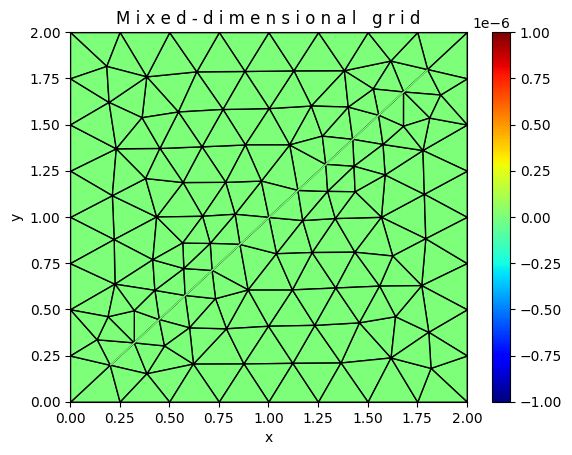

In [4]:
model_params = {}
model = SinglePhaseFlowGeometry(model_params)
pp.ModelRunner(model).run()
pp.plot_grid(model.mdg, "pressure", figsize=(10, 8), plot_2d=True)

The empty `params` implies that unitary/zero default values are used for all constants.
Similarly, the default source term and boundary conditions are zero, resulting in an absence of driving forces. 
This provides us with the constant solution shown in the figure above.

### Boundary conditions, fluid and solid constants
One example of how to include some driving forces is by defining some non-zero boundary conditions. 
This is done similarly to how we modified the geometry, meaning that we will now define a mixin for the boundary conditions. 
Methods for the boundary conditions are already present in the default model class, so modifying them can be done by overwriting the methods ``bc_type_darcy_flux`` and ``bc_values_pressure``.

In [5]:
import numpy as np
import porepy as pp
from porepy.models.fluid_mass_balance import BoundaryConditionsSinglePhaseFlow

class ModifiedBC(BoundaryConditionsSinglePhaseFlow):
    def bc_type_darcy_flux(self, sd: pp.Grid) -> pp.BoundaryCondition:
        """Assign dirichlet to the west and east boundaries. The rest are Neumann by
        default."""
        domain_sides = self.domain_boundary_sides(sd)
        bc = pp.BoundaryCondition(sd, domain_sides.west + domain_sides.east, "dir")
        return bc

    def bc_values_pressure(self, bg: pp.BoundaryGrid) -> np.ndarray:
        """Zero bc value on top and bottom, 5 on west side, 2 on east side."""
        domain_sides = self.domain_boundary_sides(bg)
        values = np.zeros(bg.num_cells)
        # See section on scaling for explanation of the conversion.
        values[domain_sides.west] = self.units.convert_units(5, "Pa")
        values[domain_sides.east] = self.units.convert_units(2, "Pa")
        return values

To combine the standard model with the new geometry _and_ the boundary conditions, we simply create a new class which inherits from all of them:

In [6]:
class SinglePhaseFlowGeometryBC(
    ModifiedGeometry,
    ModifiedBC,
    SinglePhaseFlow):
    """Adding both geometry and modified boundary conditions to the default model."""
    ...

Before we go ahead and run the model, we will also have a look at how to change parameters present in the model.
Material constants are stored in and accessed through `SolidConstants` and `FluidComponent` objects.
Instantiating these classes is how we can make adjustments of the material constants. 

This is done by creating ``fluid`` and ``solid`` dictionaries inside the ``material_constants`` dictionary, which is again located within the ``params`` dictionary.
An example is shown below.

In [7]:
fluid_constants = pp.FluidComponent(viscosity=0.1, density=0.2)
solid_constants = pp.SolidConstants(permeability=0.5, porosity=0.25)
material_constants = {"fluid": fluid_constants, "solid": solid_constants}
model_params = {"material_constants": material_constants}

Once the fluid and solid constants are defined within the ``params`` dictionary, we feed them to the model, and then run the simulation.

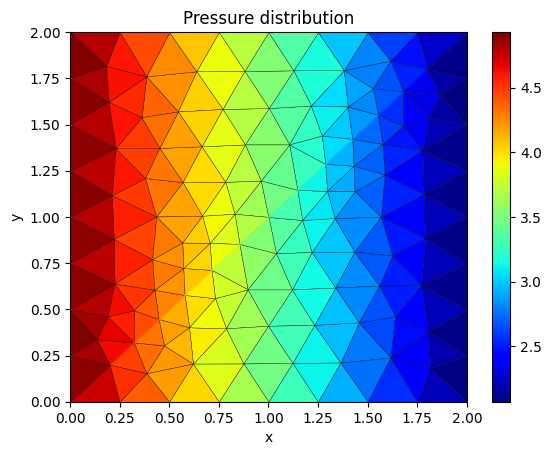

In [8]:
model = SinglePhaseFlowGeometryBC(model_params)
pp.ModelRunner(model).run()
pp.plot_grid(
    model.mdg,
    "pressure",
    figsize=(10, 8),
    linewidth=0.25,
    title="Pressure distribution",
    plot_2d=True,
)

### Fracture source
Another way to modify the model is to include a fracture source.
Below we demonstrate how a unitary fracture source can be included by a rather simple modification to the method governing the fluid source

In [9]:
class ModifiedSource:
    def fluid_source(self, subdomains: list[pp.Grid]) -> pp.ad.Operator:
        """Assign unitary fracture source"""
        # Retrieve internal sources (jump in mortar fluxes) from the base class
        internal_sources: pp.ad.Operator = super().fluid_source(subdomains)

        # Retrieve external (integrated) sources from the exact solution.
        values = []

        for sd in subdomains:
            if sd.dim == self.mdg.dim_max():
                values.append(np.zeros(sd.num_cells))
            else:
                values.append(np.ones(sd.num_cells))

        external_sources = pp.wrap_as_dense_ad_array(np.hstack(values))

        # Add up both contributions
        source = internal_sources + external_sources
        source.set_name("fluid sources")

        return source

For the sake of seeing the effects of the unitary fracture source, we do not include the non-zero boundary conditions.
This is simply done by not inheriting from ``ModifiedBC`` when creating the new model with a fracture source.

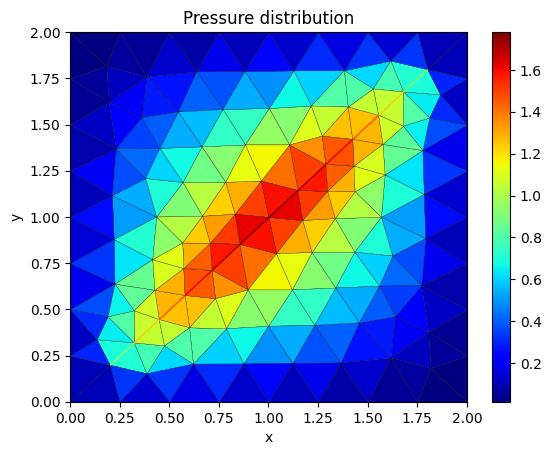

In [10]:
class SinglePhaseFlowFractureSource(ModifiedGeometry, ModifiedSource, SinglePhaseFlow):
    """Including the fracture source mixin to the default model."""

    ...


model = SinglePhaseFlowFractureSource(model_params)
pp.ModelRunner(model).run()
pp.plot_grid(
    model.mdg,
    "pressure",
    figsize=(10, 8),
    linewidth=0.2,
    title="Pressure distribution",
    plot_2d=True,
)

## Time stepping
Building upon the model with a unitary fracture source and zero boundary conditions, we will now consider how to modify the time steps of the simulation. To this end, we will add some time-dependent effects to the simulation, by setting the fluid compressibility to a non-zero value. 


In [11]:
class CompressibleFlow(
    ModifiedGeometry,
    ModifiedBC,
    ModifiedSource,
    SinglePhaseFlow
):
    """Combining modified geometry, boundary conditions and the source term with the
    default model."""
    ...


For seeing the gradual evolution of the solution we need to assign non-default values to the ``pp.TimeManager``. This means that all previous simulations have been run with only one time step, as this is the default time step amount.
Simulations with multiple time steps require users to explicitly define parameters such as time step size and the time schedule.
The time manager, with the new, non-default time parameters, is passed to the model through the ``params`` dictionary.

In [12]:
fluid_constants = pp.FluidComponent(compressibility=0.01)
material_constants = {"fluid": fluid_constants}

time_manager = pp.TimeManager(
    schedule=[0, 1e-3],
    dt_init=5e-4,
    constant_dt=True,
    iter_max=10,
    print_info=True,
)

model_params = {"material_constants": material_constants, "time_manager": time_manager}
model = CompressibleFlow(model_params)

Running the model and doing a simple visualization of the result is done in the exact same way as before:

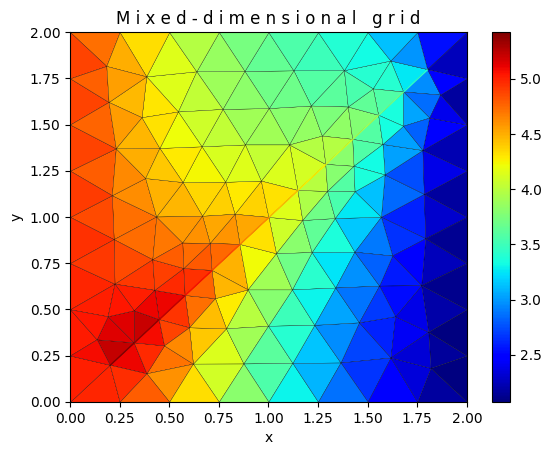

In [13]:
pp.ModelRunner(model).run()
pp.plot_grid(model.mdg, "pressure", figsize=(10, 8), linewidth=0.2, plot_2d=True)

The figure above shows the solution at the final time step. The gradual evolvement of the solution can be visualized using ParaView, see the notes below on exporting data.

## Data exporting and visualization

We end with some notes on exporting data from the simulations, for visualization purposes. By default, all the primary variables, as well as various other data such as cell and node numbers, are saved at each time step. Unless specified otherwise, all exported files are stored in a folder named `visualization` in the working directory. The folder name can be modified by use of the `folder_name` parameter as follows:

In [ ]:
model_params = {"folder_name": "my/folder/name"}

Within your chosen folder, you will find several .vtu and .pvd files, containing the exported data from the simulation. The most important of these is the file called `data.pvd`; this file will contain all of the relevant data from all time steps, and may be opened in ParaView for visualization of the solution. For users not familiar with ParaView, we recommend reading a tutorial, see for instance https://www.paraview.org/tutorials/.

See also the [exporter](./exporter.ipynb) and [exporting in models tutorial](./exporting_models.ipynb) for more advanced usage of the exporter in PorePy.

# What we have explored
We have had a look at how single physics simulations can be run with PorePy by modifying various different parts of the default models.

Specifically, we modified the following:
* Model geometry
* Boundary conditions
* Source term
* Material constants
* Time manager

We also had a look at how the simulation data is exported to formats accessible to ParaView.